PROBLEM


In a structural laboratory one of the students has found the structure of a PROBLEM protein, modelled by a previous post-doc.  However, it seems it is incomplete.  According to the experimental data,  this protein works as a tetrameric complex. But it's unclear the function and if it works at all.
Try to answer the following questions:

__a) What function do you think it may have?__

```
PDBtoSplitChain.pl -i problem_3 -o target
hmmscan /mnt/NFS_UPF/soft/databases/pfam-3/Pfam-A.hmm target.fa > targetpfam.out

Query:       target  [L=147]
Scores for complete sequence (score includes all domains):
   --- full sequence ---   --- best 1 domain ---    -#dom-
    E-value  score  bias    E-value  score  bias    exp  N  Model    Description
    ------- ------ -----    ------- ------ -----   ---- --  -------- -----------
      8e-22   77.4   0.1    1.4e-21   76.7   0.1    1.4  1  Globin    Globin
  ------ inclusion threshold ------
      0.032   14.3   0.9      0.041   13.9   0.9    1.2  1  DUF2946   Protein of unknown function (DUF2946)

```

We now know that this target protein, based on the Pfam database, comes from the `Globin` family (as it has a super lower e-value)

Take a look at the homologous sequences for the target.fa if they share same family. Then we could decipher the target's function based homology. 

This are the results from `blastp -query target.fa -db /mnt/NFS_UPF/soft/databases/blastdat/pdb_seq > target_pdb.blastp` to find close homologs. 

```
Query= target

Length=147
                                                                      Score     E
Sequences producing significant alignments:                          (Bits)  Value

1z8u_D mol:protein length:142 Hemoglobin alpha chain                  260     1e-90
1z8u_B mol:protein length:142 Hemoglobin alpha chain                  260     1e-90
1y01_B mol:protein length:142 Hemoglobin alpha chain                  260     1e-90
1bz1_C mol:protein length:142 PROTEIN (HEMOGLOBIN ALPHA CHAIN)        260     1e-90
1bz1_A mol:protein length:142 PROTEIN (HEMOGLOBIN ALPHA CHAIN)        260     1e-90
```

The top hits with a great e-value are `1z8u_D`, `1y01_B`, `1bz1_C`, so it's function is oxigen transport, electrons transport. 

__b) Does the structure of this protein belongs to some fold in SCOP?, which one?__

Search in SCOP with the PDB code of the best match of the target sequence. __SCOP (Structural Classification of Proteins) no classifica les proteïnes per la seva "família" (com fa Pfam), sinó per la seva forma 3D (Fold).__ The `1z8u_D` homolog was searched on SCOP and found its fold is globin-like and class is all-alpha. 


__c) Obtain the secondary structure with DSSP and name it p28c.dssp__

DSSP reads the 3D distance between atoms to calculate hydrogen bonds and determine the secondary structure. DSSP needs the full backbone of the protein (the Nitrogen N, the Alpha Carbon CA, the Carbonyl Carbon C, and the Oxygen O) to calculate hydrogen bonds. Since you only have CA (the "trace" of the protein), DSSP says "Incomplete Backbone" and ignores every residue, leaving you with an empty result.


```
cp /mnt/NFS_UPF/soft/databases/pdb/pdb/data/structures/divided/pdb/z8/pdb1z8u.ent.gz .
cp /mnt/NFS_UPF/soft/databases/pdb/pdb/data/structures/divided/pdb/y0/pdb1y01.ent.gz .
cp /mnt/NFS_UPF/soft/databases/pdb/pdb/data/structures/divided/pdb/bz/pdb1bz1.ent.gz .
gunzip *gz
PDBtoSplitChain.pl -i pdb1z8u.ent -o 1z8u_
PDBtoSplitChain.pl -i pdb1y01.ent -o 1y01_
PDBtoSplitChain.pl -i pdb1bz1.ent -o 1bz1_
cat 1z8u_D.fa > alignment.fa
cat 1y01_B.fa >> alignment.fa 
cat 1bz1_C.fa >> alignment.fa 
cat target.fa >> alignment.fa 

clustalw alignment.fa

aconvertMod2.pl -in c -out p < alignment.aln > alignment.pir
```

i will obtain a model and the best one will do : `dssp model.pdb p29c.dssp`



__d) Do you think the prediction of secondary structure agrees with the actual secondary structure from DSSP?. Obtain an alignment as proof and name it p28d.aln. Is the prediction reliable?__

`psipred target.fa`

Producing two files, `target.horiz`and `target.ss2`files. I will use the `target.ss2`file to convert this prediciton intothe prediction pir alignment `psipred.pl target.ss2 > psipred.pir`

Do the same but for the secondary structure from DSS `aliss_old.pl p28c.dssp > dssp.pir`.

Now we hace the predicted and the calculated seq in pir format, so concatenate them to form the `.aln`file:

```
cat psipred.pir > compare.pir
cat dssp.pir >> compare.pir 
aconvertMod2.pl -in p -out c < compare.pir > p28d.aln
```

```
CLUSTAL W(1.60) multiple sequence alignment

target.ss2Seq  VLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHGK
target.ss2SS   CCCHHHHCCCHHHHHHCCHHHHHHHHHHHHHHHHHCCCCCCCCCCCCCCCCCEECCCCHH
p28c.dsspSeq   VLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHGK
p28c.dsspSS    ---HHHHHHHHHHHHHHGGGHHHHHHHHHHHHHHH-THHHHT-SSS--STT-HHHHHHHH
p28c.dsspACC   WAGDEAIEIAFGAIDFAFBHAHDAAIIAIGHAADEGEEAGDFICBGFGECFADFIEFGAE

target.ss2Seq  KVADALTNAVAHVDDMPNALSALSDDEAHKERDDPVNDKLLSHCLLVTLAAHAPALAHLP
target.ss2SS   HHHHHHHHHHHCHHCCCHHHHHCCCHHHHHHCCCHHHHHHHHHHHHHHHHHHCHHHHCCC
p28c.dsspSeq   KVADALTNAVAHVDDMPNALSALSDDEAHKERDDPVNDKLLSHCLLVTLAAHAPALAHLP
p28c.dsspSS    HHHHHHHHHHHHTTSHHHHTHHHHHHHHHTT---THHHHHHHHHHHHHHHHT-SSSS-ST
p28c.dsspACC   DIAFHAHGAADGICDADCHAGEGAGEHAEDECHFGFAICAIAEAAAGAAHFGAAECEGID

target.ss2Seq  AEFTPAVHASLDKFLASVSTVDTSKYR
target.ss2SS   CCCCHHHHHHHHHHHHHCCCCCCCCCC
p28c.dsspSeq   AEFTPAVHASLDKFLASVSTVDTSKYR
p28c.dsspSS    TT--HHHHHHHHHHHHHHHHHHHGGG-
p28c.dsspACC   EAIGBEAFGAAFGAAFHAIEAIHEHIW
```
Comparing the second row (predicted model) with the fourht row (the actual secondary structure), overall agree in the helix regions, however the prediction at some points lcoates coils and the actual secondary structure has turns, shorts helices, etc. So for the globular core fold and the primary alpha-helical regions of the protein they agree a lot, but seembls a bit unreliable for loops as the prediction misses several bends (S) and turn (T) identified by the DSSP algorithm. 

__e) Do you think the structure is correct? Can you prove it? show an image of the energies that prove it and name it p28e.png__

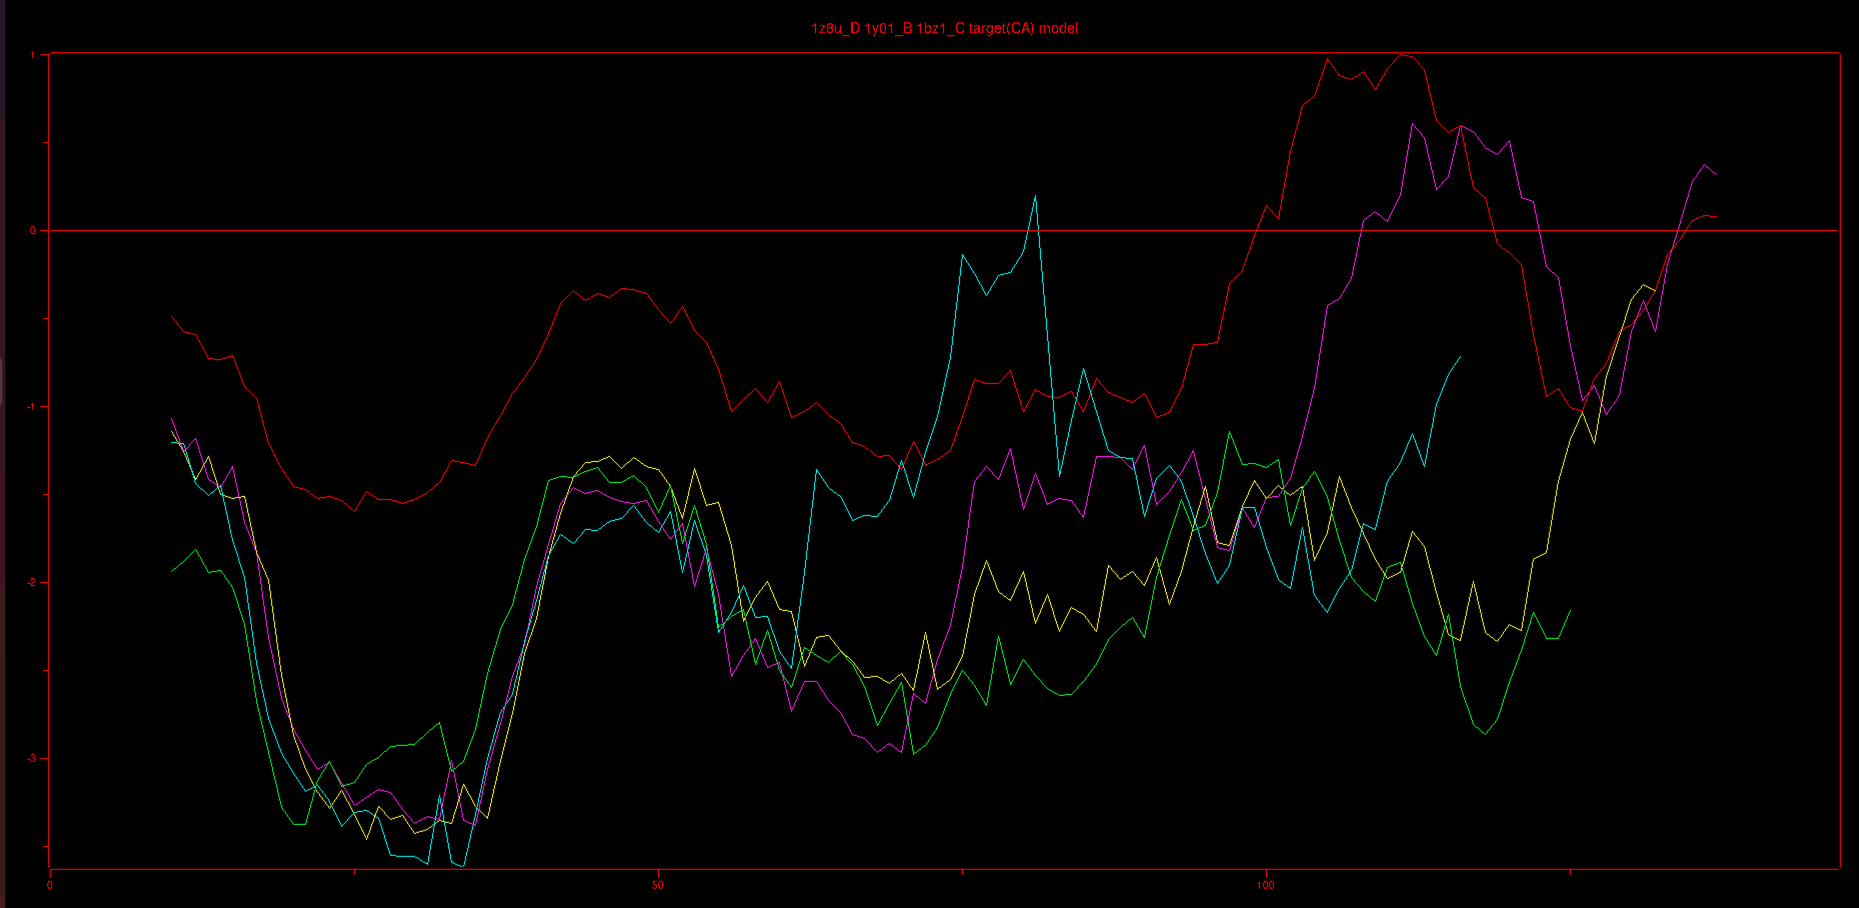

Lines green, yellow and cyan are the template, and in magenta is the model obtained from modeller. This follows the templates quite closely. This suggests that Modeller did a good job. The red is the target.pdb only containint the CA atoms, and even crosses above the 0 energy threshold. Based on the plain structure it is incorrect and structurally unstable. As shown, the energy profile of the original CA-only model (in red) is significantly higher than the profiles of the templates. While this maintin stable, engative energy values, the problem structure shows much higher internal energy thorugout the entire sequence. more improtantly, shows positvies energy in the C-terminus and that would suggest a non-antive or misfolded conformation. 

f) Find if there is some structural problem and show the location with an image (name it p28f.png). What's the sequence fragment with this problem?
g) Do you think it can work as a tetramer? show an image that can prove it (name it p28g.png)
h) If the structure of the PROBLEM was incorrect (answer in e), try to fix it. Name the new monomer model as p28h.pdb
i) Has the energy of your model improve it? Show the result with an image and name it p28i.png
j) Do you think your new model can work as a tetramer? If so, obtain the structure of the tetramer and name it p28j.pdb
k) Show with an image if the original model couldn't make a tetramer, why your new model can (or cannot) make it?. Name the image p28k.png